# Capstone Project

## Imports

In [30]:
import os
import itertools
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg
import random
from sklearn.metrics import jaccard_score
from tabulate import tabulate
from IPython.display import HTML, display
import html

In [31]:
with open("oracle-cards-20260508090243.json", "r", encoding="utf-8") as file:
    FullCardList = json.load(file)

# remove add duplicates explained below ======================================================================
before = len(FullCardList)
print("Total Before Removal: ", before)

itemsRemoved = {}
illegal = []

for c in FullCardList[:]: # copy so we can delete and iterate at same time
    if "//" in c["name"]:
        parts=c["name"].split("//")
        if parts[0].strip() == parts[1].strip():
            itemsRemoved[c["name"]] = c.items()
            FullCardList.remove(c)

print("number of items removed (//): ", len(itemsRemoved))
print("number of non-legal removed: ", len(illegal))

print("")
print("Total after removal: ", len(FullCardList))
print("Total number of items removed: ", before - (len(FullCardList)))

removeElements = ["set_type",
                  "mtgo_id",
                  "tcgplayer_id",
                  "lang",
                  "released_at",
                  "uri",
                  "scryfall_uri",
                  "highres_image",
                  "image_status",
                  "image_uris",
                  "set_uri",
                  "set_search_uri",
                  "scryfall_set_uri",
                  "rulings_uri",
                  "prints_search_uri",
                  "watermark",
                  "artist",
                  "artist_ids",
                  "illustration_id",
                  "border_color",
                  "frame",
                  "frame_effects",
                  "security_stamp",
                  "full_art",
                  "testless",
                  "booster",
                  "story_spotlight",
                  "related_uris",
                  "purchase_uris",
                  "digital",
                  "foil",
                  "nonfoil",
                  "preview",
                  "games",
                  "finishes",
                  "oversized",
                  "promo",
                  "reprint",
                  "textless"]

for card in FullCardList:
    for key in removeElements:
        card.pop(key,None)

cardsInfo = {card["name"]: card for card in FullCardList}

Total Before Removal:  37442
number of items removed (//):  2189
number of non-legal removed:  0

Total after removal:  35250
Total number of items removed:  2192


## Funcitons

In [32]:
#
# read the text files
# get out the deck list a set of unqinue cards
# and add the cards to the complete snapshot set
#
def readFiletxt(file, cardSet):

    decklist = set()
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            
            if(line.strip() == "Sideboard"):
                break
            else:
                parts = line.split(" ",1)
                #print(parts[1])
                if ( checkLands(parts[1].strip()) ):
                    continue

                else:
                    cardSet.add(parts[1].strip())
                    decklist.add(parts[1].strip())
        
    return decklist, cardSet


#
# read the mwDeck files
# get out the deck list a set of unqinue cards
# and add the cards to the complete snapshot set
#

def readFilemwDeck(file, cardSet):
    decklist = set()
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            #print(line)

            if line.startswith("//"):
                continue

            if line.startswith("SB:"):
                continue
            
            else:
                parts = line.split(" ",2)
                #print(parts[2].strip())
                if ( checkLands(parts[2].strip()) ):
                    continue

                else:
                    cardSet.add(parts[2].strip())
                    decklist.add(parts[2].strip())
        
    return decklist, cardSet

In [33]:
def checkLands(checkCard):

    typeLineCheck = ""
    pCards = []

    if "/" in checkCard:
        parts=checkCard.split("/")
        checkCard=parts[0]
        

    # if the card name flat out exists in the dict save it
    if checkCard in cardsInfo:
            typeLineCheck = cardsInfo[checkCard]["type_line"]

    else: # esle try and search for similar
        for c in FullCardList:
            if checkCard.lower() in c["name"].lower():
                pCards.append(c["name"])

        # if only one similar save it
        if (len(pCards) == 1):
            typeLineCheck = cardsInfo[pCards[0]]["type_line"]
                
        
        else:
            #print("+++++++++++++++++++++++++++++++++++++++")
            #print("")
            #print("Error")
            #print("")
            #print(checkCard)
            #print("")
            #print(pCards)
            #print("")
            #print("+++++++++++++++++++++++++++++++++++++++")
            
            #if a card name appears multiple times high likelihood of not being a land
            return False


    if ("Land" in typeLineCheck) and ("//" not in typeLineCheck):
        return True

    else:
        return False
    

In [34]:
def getSnapshot(folder):

    snapshotSet = set()
    listOfDecks = []

    for itemMajor in os.listdir(folder):
        #print(itemMajor)
        newpath = os.path.join(folder, itemMajor)
        for itemMinor in os.listdir(newpath):
            #print(itemMinor)
            newestpath = os.path.join(newpath, itemMinor)

            if newestpath.endswith(".mwDeck"):
                temp, snapshotSet = readFilemwDeck(newestpath,snapshotSet)
                listOfDecks.append(temp)
                

            if newestpath.endswith(".txt"):
                temp, snapshotSet = readFiletxt(newestpath,snapshotSet)
                listOfDecks.append(temp)
                


    print("-- Statisitcs --")
    print("   Snapshot               :" , folder)
    print("   number of cards        :" , len(snapshotSet))
    print("   number of Decks        :" , len(listOfDecks))
    print("")
    return snapshotSet, listOfDecks
                
    

In [35]:
#use sorted tuples for dictionary to form weighted edge list
# take list of unique cards in each deck
# increase dicitonary value for each time a pair appears
# return this dictionary and a dictionary of each time a card appears


def makeEdgeList(decks):

    countPairs = {} #dicitonary of pairs of cards (SORT ALPHABETICALLY) count of pairs appearance
    countCards = {} #dict of cards appearance

    for deck in decks:
        for card in deck:
            if card not in countCards:
                countCards[card] = 1

            else:
                countCards[card] += 1


        for pairs in itertools.combinations(deck,2):
            pairs = tuple(sorted(pairs))
            
            if pairs not in countPairs:
                countPairs[pairs] = 1

            else:
                countPairs[pairs] += 1

    return countCards, countPairs
    

In [36]:
#
#
# make graphs
#
def makeUndirectedGraph(edges, noDecks):

    G = nx.Graph()
    for key in edges:

        G.add_edge(key[0],key[1],weight = edges[key]/noDecks)

    return G

def makeDirectedGraph(edges, cards):

    G = nx.DiGraph()
    for key in edges:

        # (from_node , to_node) 
        # probablity of to_node, given from_node
        temp = edges[key]/ cards[key[0]]
        G.add_edge(key[0],key[1],weight=temp)

        temp = edges[key]/ cards[key[1]]
        G.add_edge(key[1],key[0],weight=temp)

    return G
    

### Graph Functions (Networks)

In [37]:
def drawGraph(G,p):

    plt.figure(figsize=(30,30))

    nodeColors="blue"

    pos = nx.spring_layout(G, k=1, iterations=10,seed=39)
    #pos = nx.kamada_kawai_layout(G)

    colourList = ["red",
                 "blue",
                 "green",
                 "skyblue",
                 "orange",
                 "yellow",
                 "purple",
                 "grey",
                 "lightgreen",
                 "pink",
                  "lime",
                  "cyan",
                  "coral",
                  
                 ]

    nodeColors = [colourList[p[node]] for node in G.nodes()]
    
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size = 500,
        node_color = nodeColors
    )
    plt.show()
    

In [38]:
def getlouvainPart(G, cards, r= True, seed = 39):

    outputDict = {}
    
    random.seed(seed)
    p = community_louvain.best_partition(G, randomize = r)
    print("Number of communities : " , len(set(p.values())))
    tempScore = community_louvain.modularity(p, G)
    print("Modularity Score      : " ,  tempScore)
    print("")

    for i in set(p.values()):
        temp = []

        for node in p:
            if p[node] == i:
                temp.append((node, cards[node]))


        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1

        outputDict["com" + str(i)] = sortedD
        print("")
        print("")
        print("")
    return p , outputDict


def getleidenPart(G, cards):
    return 0

In [39]:
def getPagerank(G, seePRNumber, coms):
    
    p = nx.pagerank(G, weight="weight")
    pSorted = sorted(p.items(), key=lambda x: x[1], reverse=True)

    print("             Top ",seePRNumber," cards by Page Rank Overall")
    x = 0
    while x < seePRNumber:
        print(pSorted[x])
        x +=1

    print("")
    print("")
    print("")
    
    
    for i in set(coms.values()):
        temp = []

        for node in coms:
            if coms[node] == i:
                temp.append((node, p[node]))
        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1
                
        print("")
        print("")
        print("")
        
    return p

    

In [40]:
def graphStats(G):

    # universal stats =========================================================
    noNodes = G.number_of_nodes()
    noEdges = G.number_of_edges()
    density = nx.density(G)

    print("number of Nodes                          : " , noNodes)
    print("number of Edges                          : " , noEdges)
    print("density (fraction of all possible nodes) : " , density)

    # undirected stats ===================================================
    if not nx.is_directed(G): #undirected 
        avgDegree = 0
        for node, deg in G.degree:
            avgDegree += deg

        avgDegree = avgDegree/noNodes
        print("Average degree                           : ", avgDegree)

        
        avgEdgeW = 0
        temp = G.edges(data=True)
        for n in temp:
            avgEdgeW += n[2]["weight"]

        avgEdgeW = avgEdgeW/noEdges
        print("Average Edge Weight                      : ", avgEdgeW)

        


    #directed stats===========================================
    else:
        avgInDegree = 0
        for node, value in G.in_degree():
            avgInDegree += value

        avgInDegree = avgInDegree/noNodes
        print("Average In degree                         : ", avgInDegree)
        
        avgOutDegree = 0
        for node, value in G.out_degree():
            avgOutDegree += value

        avgOutDegree = avgOutDegree/noNodes
        print("Average Out degree                        : ", avgOutDegree)
    

    #number of connected components
    
    print("")
    print("")
    return noNodes
    

### Main body function

In [41]:
def snapToGraph(pathway, cardSetSoFar):

    cardsInSnap = set()

    #parse the snapshot and get a set of all the cards
    # and a list of sets of all the decks
    # i.e each deck but only the unique cards in said deck
    cardset, decks = getSnapshot(pathway)

    #get card occurances
    #get pairwise occurances
    cardsOcc, pairsOcc = makeEdgeList(decks)

    # return a constructed directed graph
    # return a constructed undriected graph
    # both are weighted
    #

    #return the updated cards set
    cardSetSoFar.update(cardset) # this is so we have a set which can be built upon and will contain all cards period
    cardsInSnap.update(cardset) # this is so we have a set of exclusively this snapshot
    #print("length : ", len(decks))
    print("# cards that have appeared so far :", len(cardSetSoFar))

    graph = makeUndirectedGraph(pairsOcc, len(decks) )
    digraph = makeDirectedGraph(pairsOcc, cardsOcc)

    print("")
    print("------------- Undirected Graph Stats -------------")
    graphStats(graph)
    comms, commsDict = getlouvainPart(graph, cardsOcc, r= True)


    print("")
    print("------------- Directed Graph Stats -------------")
    graphStats(digraph)

    cardsPageRank = getPagerank(digraph, 10, comms)

    
    cardsOccNorm = cardsOcc.copy()
    for name,x in cardsOccNorm.items():
        cardsOccNorm[name]= x /len(decks)
    
    return graph, digraph, cardSetSoFar, cardsOcc, commsDict, cardsInSnap, cardsPageRank, cardsOccNorm

### Comparison functions

In [42]:
def jaccardSim(com1, com2, verbose):

    temp1 = []
    for x in com1:
        temp1.append(x[0])

    temp2 = []
    for x in com2:
        temp2.append(x[0])
    
    set1 = set(temp1)
    set2= set(temp2)
    
    top = len( (set1).intersection(set2) )
    bot = len( (set1).union(set2) )

    if(verbose):
        print(top)
        print(bot)
        print((set1).intersection(set2))
    return top/bot, top

In [43]:
def removeFromSet(RemoveFrom,beingRemoved):
    temp1 = []
    for x in beingRemoved:
        temp1.append(x[0]) # this is now a clean without scores

    return RemoveFrom - set(temp1)

def compareIntersect(comparison1, comparison2):
    temp1 = []
    for x in comparison2:
        temp1.append(x[0]) # this is now a clean without scores
    return len(comparison1.intersection(set(temp1)))
    

In [44]:
def jaccardTable(i,j, snap1, cards1, snap2, cards2):
    #compare all of the two snapshots communities

    total = cards1.union(cards2) # every unique card in both snapshots
    finalCardTotal = 0
    
    tab = [] #this is what will be printed out using tabulate
    for name1,x in snap1.items():
        temp = []
        headings = [] # keep track of headings
        headings.append(str(i) + "\\" + str(j)) # first slot can just be empty
        headings.append("# in Community")
        temp.append(name1)
        temp.append(len(x))
        cardsAccountedFor = 0
        tempTotal = total.copy() # copy over so i can reuse
        
        for name2,y in snap2.items():
            
            tempTotal = removeFromSet(tempTotal,y)
            headings.append(name2)
            out, add = jaccardSim(x, y, False) #print "out". sum "add" to make sure all cards are accounted for
            cardsAccountedFor += add
            temp.append(out)
            

        temp.append(cardsAccountedFor)
        tempintersect = compareIntersect(tempTotal, x)
        temp.append(tempintersect)
        finalCardTotal += cardsAccountedFor + tempintersect
        tab.append(temp)
    headings.append("Cards Accounted For")
    headings.append("Cards Unaccounted For")
    outputTable = tabulate(tab, headers=headings, tablefmt="grid")

    display(HTML(f"""
    </div style="overflow-x: auto; width:100%;">
    <pre style="white-space:pre; font-family:monospace;">{html.escape(outputTable)}</pre>
    
    </div>
    """))
    return finalCardTotal

## Graphing functions (Temporal)

In [45]:
def graphOverTime(Cardname, stats):

    temp = []
    for x in stats:
        if Cardname in x:
            temp.append(x[Cardname])

        else:
            temp.append(None)

    plt.plot(range(len(temp)), temp, marker="o")
    plt.xticks(range(len(temp)))
    plt.show()
    return temp

## Rough work

### test land checker

In [46]:
print(checkLands("Gohn, Town of Ruin")) #card
print("True") 
print("")

print(checkLands("Treasure Map") )
print("False") 
print("")

print(checkLands("Matzalantli")) #card
print("False") #expected result
print("")

print(checkLands("Matzalantli, the great door")) #card
print("False") #expected result
print("")

print(checkLands("Mountain"))
print("True") #expected result
print("")

True
True

False
False

False
False

False
False

True
True



### test methods

In [47]:
totalcards = set()
pageranks = []
cardOccurancesNorm = []
g1, diG1, totalcards, cardOccurances1, communityList1, snap1Cards, pagerank1, cardOccurancesNorm1 = snapToGraph("decklists\\Snapshot 1", totalcards)
pageranks.append(pagerank1)
cardOccurancesNorm.append(cardOccurancesNorm1)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 1
   number of cards        : 403
   number of Decks        : 697

# cards that have appeared so far : 403

------------- Undirected Graph Stats -------------
number of Nodes                          :  403
number of Edges                          :  5852
density (fraction of all possible nodes) :  0.07224423786773329
Average degree                           :  29.042183622828784
Average Edge Weight                      :  0.011863410319197706


Number of communities :  11
Modularity Score      :  0.6065360155806082

  ===== Communitiy  0  =====
10
('Legion Extruder', 1)
('Radiant Lotus', 1)
('Boommobile', 1)
('Thran Spider', 1)
("Collector's Vault", 1)
('Chainsaw', 1)
('Repurposing Bay', 1)
('The Enigma Jewel', 1)
('Memory Guardian', 1)
('Simulacrum Synthesizer', 1)



  ===== Communitiy  1  =====
42
('Kaito, Bane of Nightmares', 172)
('Nowhere to Run', 148)
("Stormchaser's Talent", 137)
('Hopeless Nightmare', 133)
("This

In [48]:
g2, diG2, totalcards, cardOccurances2, communityList2 , snap2Cards, pagerank2, cardOccurancesNorm2  = snapToGraph("decklists\\Snapshot 2", totalcards)
pageranks.append(pagerank2)
cardOccurancesNorm.append(cardOccurancesNorm2)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 2
   number of cards        : 415
   number of Decks        : 986

# cards that have appeared so far : 565

------------- Undirected Graph Stats -------------
number of Nodes                          :  415
number of Edges                          :  6530
density (fraction of all possible nodes) :  0.07601420173447412
Average degree                           :  31.46987951807229
Average Edge Weight                      :  0.011464173777449268


Number of communities :  7
Modularity Score      :  0.5370680172046391

  ===== Communitiy  0  =====
36
('Stock Up', 464)
('Monstrous Rage', 413)
('Monastery Swiftspear', 360)
('Burst Lightning', 355)
("Stormchaser's Talent", 342)
('Into the Flood Maw', 337)
('Cori-Steel Cutter', 330)
('Sleight of Hand', 318)
('Opt', 316)
('Torch the Tower', 300)



  ===== Communitiy  1  =====
42
('Heartfire Hero', 118)
('Emberheart Challenger', 116)
('Screaming Nemesis', 112)
('Manifold Mouse', 11

In [49]:
g3, diG3, totalcards, cardOccurances3, communityList3 , snap3Cards, pagerank3, cardOccurancesNorm3  = snapToGraph("decklists\\Snapshot 3", totalcards)
pageranks.append(pagerank3)
cardOccurancesNorm.append(cardOccurancesNorm3)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 3
   number of cards        : 213
   number of Decks        : 210

# cards that have appeared so far : 594

------------- Undirected Graph Stats -------------
number of Nodes                          :  213
number of Edges                          :  2289
density (fraction of all possible nodes) :  0.10138187616263619
Average degree                           :  21.492957746478872
Average Edge Weight                      :  0.029742661590631485


Number of communities :  6
Modularity Score      :  0.6224609371913772

  ===== Communitiy  0  =====
39
('Preacher of the Schism', 30)
('Go for the Throat', 28)
('Cut Down', 28)
('Duress', 26)
('Kaito, Bane of Nightmares', 24)
('Enduring Curiosity', 24)
('Floodpits Drowner', 23)
('Spyglass Siren', 22)
('Sheoldred, the Apocalypse', 22)
("Gix's Command", 21)



  ===== Communitiy  1  =====
26
('Stock Up', 75)
('Opt', 64)
('Cori-Steel Cutter', 64)
("Stormchaser's Talent", 63)
('Sleigh

In [50]:
g4, diG4, totalcards, cardOccurances4, communityList4, snap4Cards, pagerank4, cardOccurancesNorm4 = snapToGraph("decklists\\Snapshot 4", totalcards)
pageranks.append(pagerank4)
cardOccurancesNorm.append(cardOccurancesNorm4)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 4
   number of cards        : 423
   number of Decks        : 325

# cards that have appeared so far : 704

------------- Undirected Graph Stats -------------
number of Nodes                          :  423
number of Edges                          :  5764
density (fraction of all possible nodes) :  0.0645804622813799
Average degree                           :  27.252955082742318
Average Edge Weight                      :  0.014482997918111333


Number of communities :  9
Modularity Score      :  0.6150390977185033

  ===== Communitiy  0  =====
55
('Llanowar Elves', 48)
('Overprotect', 20)
('Screaming Nemesis', 19)
('Snakeskin Veil', 16)
('Bushwhack', 15)
('Twinmaw Stormbrood', 14)
('Bristly Bill, Spine Sower', 14)
('Mossborn Hydra', 14)
('Traveling Chocobo', 14)
("Sazh's Chocobo", 14)



  ===== Communitiy  1  =====
14
('Assimilation Aegis', 2)
('Ishgard, the Holy See', 2)
('Cryptic Coat', 1)
("Kayla's Reconstruction", 1)


In [51]:
g5, diG5, totalcards, cardOccurances5, communityList5, snap5Cards, pagerank5, cardOccurancesNorm5 = snapToGraph("decklists\\Snapshot 5", totalcards)
pageranks.append(pagerank5)
cardOccurancesNorm.append(cardOccurancesNorm5)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 5
   number of cards        : 211
   number of Decks        : 184

# cards that have appeared so far : 752

------------- Undirected Graph Stats -------------
number of Nodes                          :  211
number of Edges                          :  2153
density (fraction of all possible nodes) :  0.09717896637327916
Average degree                           :  20.407582938388625
Average Edge Weight                      :  0.03201044043700466


Number of communities :  6
Modularity Score      :  0.6686189169688097

  ===== Communitiy  0  =====
21
('Tragic Trajectory', 33)
('Spyglass Siren', 27)
('Long Goodbye', 27)
('Enduring Curiosity', 27)
('Cecil, Dark Knight', 26)
('Kaito, Bane of Nightmares', 26)
('Floodpits Drowner', 26)
('Preacher of the Schism', 24)
('Bitter Triumph', 24)
('Phantom Interference', 20)



  ===== Communitiy  1  =====
40
('Burst Lightning', 51)
('Hired Claw', 50)
('Screaming Nemesis', 49)
('Razorkin N

In [52]:
g6, diG6, totalcards, cardOccurances6, communityList6, snap6Cards, pagerank6, cardOccurancesNorm6 = snapToGraph("decklists\\Snapshot 6", totalcards)
pageranks.append(pagerank6)
cardOccurancesNorm.append(cardOccurancesNorm6)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 6
   number of cards        : 349
   number of Decks        : 542

# cards that have appeared so far : 825

------------- Undirected Graph Stats -------------
number of Nodes                          :  349
number of Edges                          :  4236
density (fraction of all possible nodes) :  0.0697559529690742
Average degree                           :  24.275071633237822
Average Edge Weight                      :  0.016626072776307954


Number of communities :  6
Modularity Score      :  0.6672174419240627

  ===== Communitiy  0  =====
49
('Hired Claw', 124)
('Screaming Nemesis', 120)
('Burst Lightning', 119)
('Razorkin Needlehead', 116)
('Nova Hellkite', 116)
('Burnout Bashtronaut', 116)
('Lightning Strike', 110)
('Witchstalker Frenzy', 101)
('Emberheart Challenger', 101)
('Scalding Viper', 45)



  ===== Communitiy  1  =====
32
('Quantum Riddler', 199)
('Abrade', 192)
('Into the Flood Maw', 188)
('Winternight Sto

In [53]:
g7, diG7, totalcards, cardOccurances7, communityList7, snap7Cards, pagerank7, cardOccurancesNorm7 = snapToGraph("decklists\\Snapshot 7", totalcards)
pageranks.append(pagerank7)
cardOccurancesNorm.append(cardOccurancesNorm7)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 7
   number of cards        : 524
   number of Decks        : 889

# cards that have appeared so far : 979

------------- Undirected Graph Stats -------------
number of Nodes                          :  524
number of Edges                          :  8729
density (fraction of all possible nodes) :  0.06370323880139536
Average degree                           :  33.31679389312977
Average Edge Weight                      :  0.008171693053203513


Number of communities :  7
Modularity Score      :  0.596400002598311

  ===== Communitiy  0  =====
81
('Burst Lightning', 98)
('Hired Claw', 77)
('Nova Hellkite', 73)
('Lightning Strike', 54)
('Burnout Bashtronaut', 52)
('Shock', 47)
('Razorkin Needlehead', 47)
('Tersa Lightshatter', 44)
('Emberheart Challenger', 40)
('Ojer Axonil, Deepest Might', 37)



  ===== Communitiy  1  =====
28
('Cryogen Relic', 24)
('Grim Bauble', 19)
('Perilous Snare', 18)
('Pinnacle Starcage', 18)
('Unit

In [54]:
g8, diG8, totalcards, cardOccurances8, communityList8, snap8Cards, pagerank8, cardOccurancesNorm8 = snapToGraph("decklists\\Snapshot 8", totalcards)
pageranks.append(pagerank8)
cardOccurancesNorm.append(cardOccurancesNorm8)

-- Statisitcs --
   Snapshot               : decklists\Snapshot 8
   number of cards        : 410
   number of Decks        : 678

# cards that have appeared so far : 1050

------------- Undirected Graph Stats -------------
number of Nodes                          :  410
number of Edges                          :  6267
density (fraction of all possible nodes) :  0.07474506529906375
Average degree                           :  30.570731707317073
Average Edge Weight                      :  0.011177149775030964


Number of communities :  7
Modularity Score      :  0.5419423326264892

  ===== Communitiy  0  =====
91
('Stock Up', 162)
('Requiting Hex', 148)
('Bitter Triumph', 145)
('Winternight Stories', 111)
('Deceit', 106)
('Superior Spider-Man', 87)
('Shoot the Sheriff', 73)
('Harvester of Misery', 73)
('Enduring Curiosity', 72)
('Floodpits Drowner', 66)



  ===== Communitiy  1  =====
95
('Llanowar Elves', 183)
('Badgermole Cub', 174)
('Mightform Harmonizer', 122)
('Icetill Explorer', 11

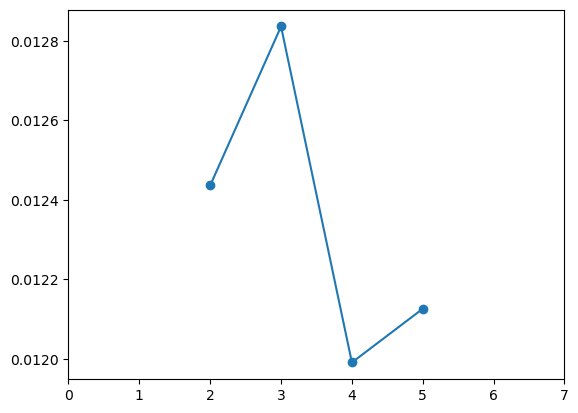

[None,
 None,
 0.012436251531701652,
 0.012836451577767773,
 0.011990462281052825,
 0.012125700252008039,
 None,
 None]

In [55]:
#Dragonhawk, Fate's Tempest
graphOverTime("Vivi Ornitier", pageranks)

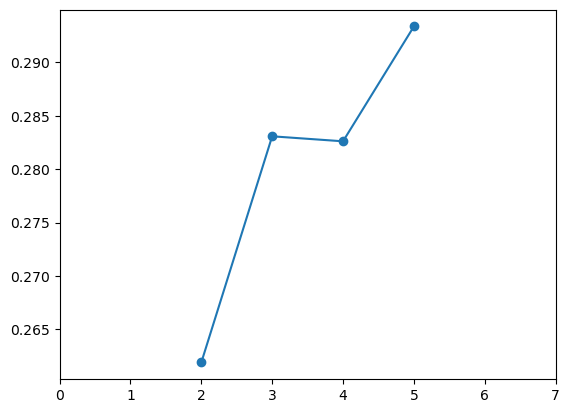

[None,
 None,
 0.2619047619047619,
 0.28307692307692306,
 0.2826086956521739,
 0.2933579335793358,
 None,
 None]

In [56]:
graphOverTime("Vivi Ornitier", cardOccurancesNorm)

In [57]:
jaccardTable(1,2, communityList1, snap1Cards, communityList2, snap2Cards)

403

In [58]:
pagerank1

{'Case of the Gateway Express': 0.002316886032946903,
 'Gleeful Demolition': 0.002316886032946903,
 'Oltec Matterweaver': 0.0005391363444866024,
 'Warden of the Inner Sky': 0.002906680622767949,
 'Dusk Rose Reliquary': 0.0015112678305424755,
 'Nesting Bot': 0.002805931605294314,
 'Novice Inspector': 0.002906680622767949,
 "Imodane's Recruiter": 0.002651885655405964,
 "Warleader's Call": 0.0008825461065403736,
 'Resolute Reinforcements': 0.002316886032946903,
 'Knight-Errant of Eos': 0.0035202377986408777,
 'Kaito, Bane of Nightmares': 0.013946874100172665,
 'Momentum Breaker': 0.008618214336141083,
 'Hopeless Nightmare': 0.010482644548172177,
 "Stormchaser's Talent": 0.01138641905631715,
 'Shoot the Sheriff': 0.006016390128185178,
 'Grim Bauble': 0.002035473047610227,
 'Get Out': 0.0009915182148696909,
 'Spyglass Siren': 0.011644771456258838,
 'Spell Pierce': 0.007673422278806017,
 "This Town Ain't Big Enough": 0.010946252029575537,
 'Fear of Isolation': 0.010306854572490096,
 'Nowhere

In [59]:
cardOccurancesNorm1

{'Gleeful Demolition': 0.018651362984218076,
 'Case of the Gateway Express': 0.018651362984218076,
 'Oltec Matterweaver': 0.0014347202295552368,
 'Warden of the Inner Sky': 0.02582496413199426,
 'Dusk Rose Reliquary': 0.007173601147776184,
 'Nesting Bot': 0.018651362984218076,
 'Novice Inspector': 0.02582496413199426,
 "Imodane's Recruiter": 0.020086083213773313,
 "Warleader's Call": 0.00430416068866571,
 'Resolute Reinforcements': 0.018651362984218076,
 'Knight-Errant of Eos': 0.02295552367288379,
 'Kaito, Bane of Nightmares': 0.2467718794835007,
 'Momentum Breaker': 0.15064562410329985,
 'Hopeless Nightmare': 0.1908177905308465,
 "Stormchaser's Talent": 0.19655667144906744,
 'Shoot the Sheriff': 0.0703012912482066,
 'Grim Bauble': 0.02582496413199426,
 'Get Out': 0.011477761836441894,
 'Spyglass Siren': 0.16212338593974174,
 'Spell Pierce': 0.10616929698708752,
 "This Town Ain't Big Enough": 0.1908177905308465,
 'Fear of Isolation': 0.18651362984218078,
 'Nowhere to Run': 0.212338593